In [2]:
#import packages
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.float_format = '{:,.0f}'.format

In [3]:
#Download DATA
ticker = yf.Ticker("AAPL")

df = yf.download(tickers= "AAPL", start= "2025-01-01", end="2025-12-31", group_by= "columns")
stockprice = df["AAPL"]["Close"]["2025-09-30"]

#Balance Sheet
bs = ticker.balance_sheet

#Income Statement
income_stmt = ticker.income_stmt

#CashFlow
cashflow = ticker.cashflow

[*********************100%***********************]  1 of 1 completed


In [4]:
##Simple Plan Model
#Simple Income Statement
sales = income_stmt.loc["Total Revenue"]
costs = income_stmt.loc['Total Expenses']
net_income = sales - costs
dividends = -cashflow.loc["Cash Dividends Paid"]
retained_earning = net_income-dividends

simple_income_stmt = pd.DataFrame({
    "sales":sales,
    "costs" : costs,
    "net_income" : net_income,
    "Dividends" : dividends,
    "retained_earning" : retained_earning
}, index = ["2025-09-30"])

simple_income_stmt.T

,2025-09-30
sales,"416,161,000,000"
costs,"283,111,000,000"
net_income,"133,050,000,000"
Dividends,"15,421,000,000"
retained_earning,"117,629,000,000"


In [5]:
#Simple Balance Sheet
simple_total_assets = bs.loc["Total Assets"]
simple_total_debt = bs.loc["Total Liabilities Net Minority Interest"]
simple_total_equity = bs.loc["Stockholders Equity"]

simple_balance_sheet = pd.DataFrame({
    "asset" : simple_total_assets,
    "debt" : simple_total_debt,
    "equity" : simple_total_equity
}, index=["2025-09-30"])

simple_balance_sheet.T

,2025-09-30
asset,"359,241,000,000"
debt,"285,508,000,000"
equity,"73,733,000,000"


In [6]:
#Make Target income statement, the aim is 20%
aim = 0.2

future_sales = sales["2025-09-30"] * (1+aim)
future_costs = costs["2025-09-30"] * (1+aim)
future_net_income = future_sales - future_costs
future_dividends = dividends["2025-09-30"] *(1+aim)
future_retained_earn = retained_earning["2025-09-30"]*(1+aim)

future_income_stmt = pd.DataFrame({
    "sales": future_sales,
    "costs" : future_costs,
    "net_income" : future_net_income,
    "Dividends" : future_dividends,
    "retained_earning" : future_retained_earn
}, index = ["future"])


income_stmt_result = pd.concat([simple_income_stmt, future_income_stmt])

income_stmt_result.T

,2025-09-30,future
sales,"416,161,000,000","499,393,200,000"
costs,"283,111,000,000","339,733,200,000"
net_income,"133,050,000,000","159,660,000,000"
Dividends,"15,421,000,000","18,505,200,000"
retained_earning,"117,629,000,000","141,154,800,000"


In [7]:
#Make Target Balance Sheet, the aim is 20%

future_total_asset = simple_total_assets["2025-09-30"] * (1+aim)
future_total_equity = simple_total_equity["2025-09-30"] + future_net_income
future_total_debt = future_total_asset - future_total_equity


future_balance_sheet = pd.DataFrame({
    "asset" : future_total_asset,
    "debt" : future_total_debt,
    "equity" : future_total_equity
}, index = ["future"])

balance_sheet_result = pd.concat([simple_balance_sheet, future_balance_sheet])
balance_sheet_result.T


,2025-09-30,future
asset,"359,241,000,000","431,089,200,000"
debt,"285,508,000,000","197,696,200,000"
equity,"73,733,000,000","233,393,000,000"


In [8]:
#Percentage of Sales Approach
pd.options.display.float_format = '{:.2f}'.format

dividends_payout_ratio = dividends/net_income
dividends_payout_ratio = dividends_payout_ratio["2025-09-30"]

retention_ratio = 1-dividends_payout_ratio


In [9]:
#EFN and Growth
future_balance_sheet_1 = pd.DataFrame({
    "asset" : future_total_asset,
    "debt" : simple_total_debt,
    "equity" : future_total_equity
}, index = ["2025-09-30"])

future_total_asset - simple_total_debt - future_total_equity
#we don't need EFN because it already '-'

2025-09-30    -87811800000.00
2024-09-30   -110333800000.00
2023-09-30    -92740800000.00
2022-09-30   -104386800000.00
2021-09-30                NaN
Name: Total Liabilities Net Minority Interest, dtype: float64

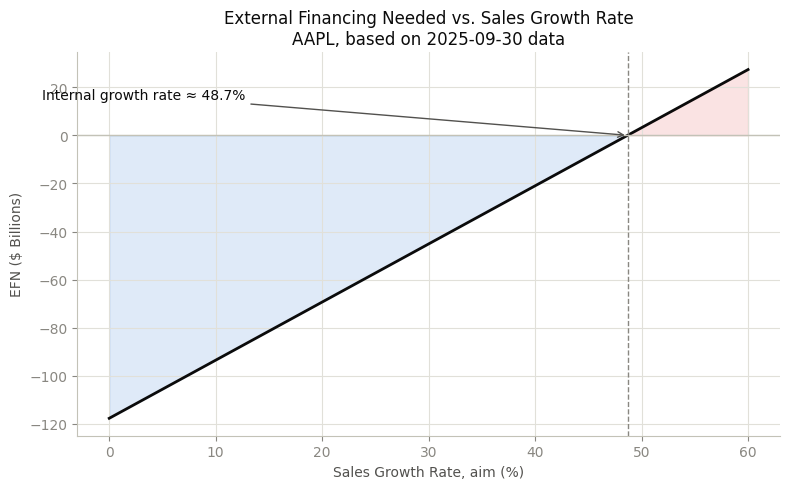

In [11]:
#EFN as a function of the growth rate (aim) _ it made  by Claude code
import matplotlib.pyplot as plt

sales_0 = sales["2025-09-30"]
assets_0 = simple_total_assets["2025-09-30"]
net_income_0 = net_income["2025-09-30"]
b = retention_ratio

growth_rates = np.linspace(0, 0.6, 200)

#EFN(g) = required increase in assets - addition to retained earnings
required_asset_increase = assets_0 * growth_rates
addition_to_re = b * net_income_0 * (1 + growth_rates)
efn = required_asset_increase - addition_to_re
efn_billion = efn / 1e9

#Internal Growth Rate: g where EFN = 0 -> (b*NI0) / (Assets0 - b*NI0)
internal_growth_rate = (b * net_income_0) / (assets_0 - b * net_income_0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(growth_rates * 100, efn_billion, color="#0b0b0b", linewidth=2)
ax.fill_between(growth_rates * 100, efn_billion, 0, where=(efn_billion >= 0), color="#e34948", alpha=0.15)
ax.fill_between(growth_rates * 100, efn_billion, 0, where=(efn_billion <= 0), color="#2a78d6", alpha=0.15)
ax.axhline(0, color="#c3c2b7", linewidth=1)
ax.axvline(internal_growth_rate * 100, color="#898781", linewidth=1, linestyle="--")

ax.annotate(f"Internal growth rate ≈ {internal_growth_rate*100:.1f}%",
            xy=(internal_growth_rate * 100, 0),
            xytext=(internal_growth_rate * 100 - 55, efn_billion.max() * 0.55),
            arrowprops=dict(arrowstyle="->", color="#52514e"),
            color="#0b0b0b", fontsize=10)

ax.set_xlabel("Sales Growth Rate, aim (%)", color="#52514e")
ax.set_ylabel("EFN ($ Billions)", color="#52514e")
ax.set_title("External Financing Needed vs. Sales Growth Rate\nAAPL, based on 2025-09-30 data", color="#0b0b0b")
ax.grid(True, color="#e1e0d9", linewidth=0.8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#c3c2b7")
ax.tick_params(colors="#898781")

plt.tight_layout()
plt.show()

In [ ]:
#Internal Growth Rate(IGR) is ROA*b / 1-ROA*b
roa = net_income / simple_total_assets
igr = (roa*retention_ratio) / (1-(roa*retention_ratio))

igr

2025-09-30   0.49
2024-09-30   0.43
2023-09-30   0.40
2022-09-30   0.43
2021-09-30    NaN
dtype: float64

In [ ]:
#Sustainable Growth Rate(SGR) is ROE*b / 1-ROE*b 
roe = net_income/simple_total_equity
sgr = (roe*retention_ratio) / (1-(roe*retention_ratio))


# SGR breaks down here: ROE * b > 1 (Apple's book equity is tiny after years of
# buybacks, so ROE is ~180%), making (1 - ROE*b) negative and flipping the sign.
# Not a bug — the equity-only-financing assumption behind this formula just
# doesn't hold for a thin-equity firm like this. IGR is fine since ROA*b < 1.


2025-09-30   -2.68
2024-09-30   -2.10
2023-09-30   -2.60
2022-09-30   -1.92
2021-09-30     NaN
dtype: float64